Імпорти

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)

import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
)

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import (
    DISTILBERT_MODEL_ID,
    TEST_PATH,
)

1. Завантажуємо тестові дані

In [3]:
test_df = pd.read_csv(TEST_PATH)

print(test_df.shape)

test_df.head(5)

(3080, 4)


,text,label,label_text,text_clean
0,How do I locate my card?,11,card_arrival,how do i locate my card?
1,"I still have not received my new card, I order...",11,card_arrival,"i still have not received my new card, i order..."
2,I ordered a card but it has not arrived. Help ...,11,card_arrival,i ordered a card but it has not arrived. help ...
3,Is there a way to know when my card will arrive?,11,card_arrival,is there a way to know when my card will arrive?
4,My card has not arrived yet.,11,card_arrival,my card has not arrived yet.


2. Завантажуємо моделі

In [4]:
tokenizer = AutoTokenizer.from_pretrained(
    DISTILBERT_MODEL_ID
)

model = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT_MODEL_ID
)

device = (
    "cuda"
    if torch.cuda.is_available()
    else (
        "mps"
        if torch.backends.mps.is_available()
        else "cpu"
    )
)

model.to(device)

model.eval()

print(device)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

mps


3. Робимо передбачення

In [5]:
from torch.utils.data import DataLoader

texts = test_df["text"].tolist()

encodings = tokenizer(
    texts,
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors="pt",
)

dataset = torch.utils.data.TensorDataset(
    encodings["input_ids"],
    encodings["attention_mask"],
)

loader = DataLoader(
    dataset,
    batch_size=32,
)

In [6]:
predictions = []
probabilities = []

with torch.no_grad():

    for batch in loader:

        input_ids, attention_mask = [
            x.to(device)
            for x in batch
        ]

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        probs = torch.softmax(
            outputs.logits,
            dim=1,
        )

        pred = probs.argmax(dim=1)

        predictions.extend(
            pred.cpu().numpy()
        )

        probabilities.extend(
            probs.max(dim=1).values.cpu().numpy()
        )

In [7]:
test_df["prediction"] = predictions

test_df["confidence"] = probabilities

test_df["correct"] = (
    test_df["prediction"]
    == test_df["label"]
)

4. Робимо Classification Report

In [8]:
report = classification_report(
    test_df["label"],
    test_df["prediction"],
    target_names=sorted(
        test_df["label_text"].unique()
    ),
    output_dict=True,
)

report_df = (
    pd.DataFrame(report)
    .transpose()
)

report_df.head()

,precision,recall,f1-score,support
Refund_not_showing_up,1.000000,0.975,0.987342,40.0
activate_my_card,0.975610,1.000,0.987654,40.0
age_limit,1.000000,1.000,1.000000,40.0
apple_pay_or_google_pay,1.000000,0.975,0.987342,40.0
atm_support,0.973684,0.925,0.948718,40.0


5. ТОП-15 найгірших intent

In [9]:
intent_report = (
    report_df
    .iloc[:-3]
    .sort_values(
        "f1-score"
    )
)

intent_report.head(15)

,precision,recall,f1-score,support
why_verify_identity,0.787879,0.650,0.712329,40.0
topping_up_by_card,0.769231,0.750,0.759494,40.0
automatic_top_up,0.848485,0.700,0.767123,40.0
virtual_card_not_working,1.000000,0.625,0.769231,40.0
verify_my_identity,0.708333,0.850,0.772727,40.0
fiat_currency_support,0.750000,0.825,0.785714,40.0
card_acceptance,0.772727,0.850,0.809524,40.0
declined_cash_withdrawal,0.965517,0.700,0.811594,40.0
change_pin,0.861111,0.775,0.815789,40.0
transfer_not_received_by_recipient,0.795455,0.875,0.833333,40.0


6. Робимо Confusion Matrix

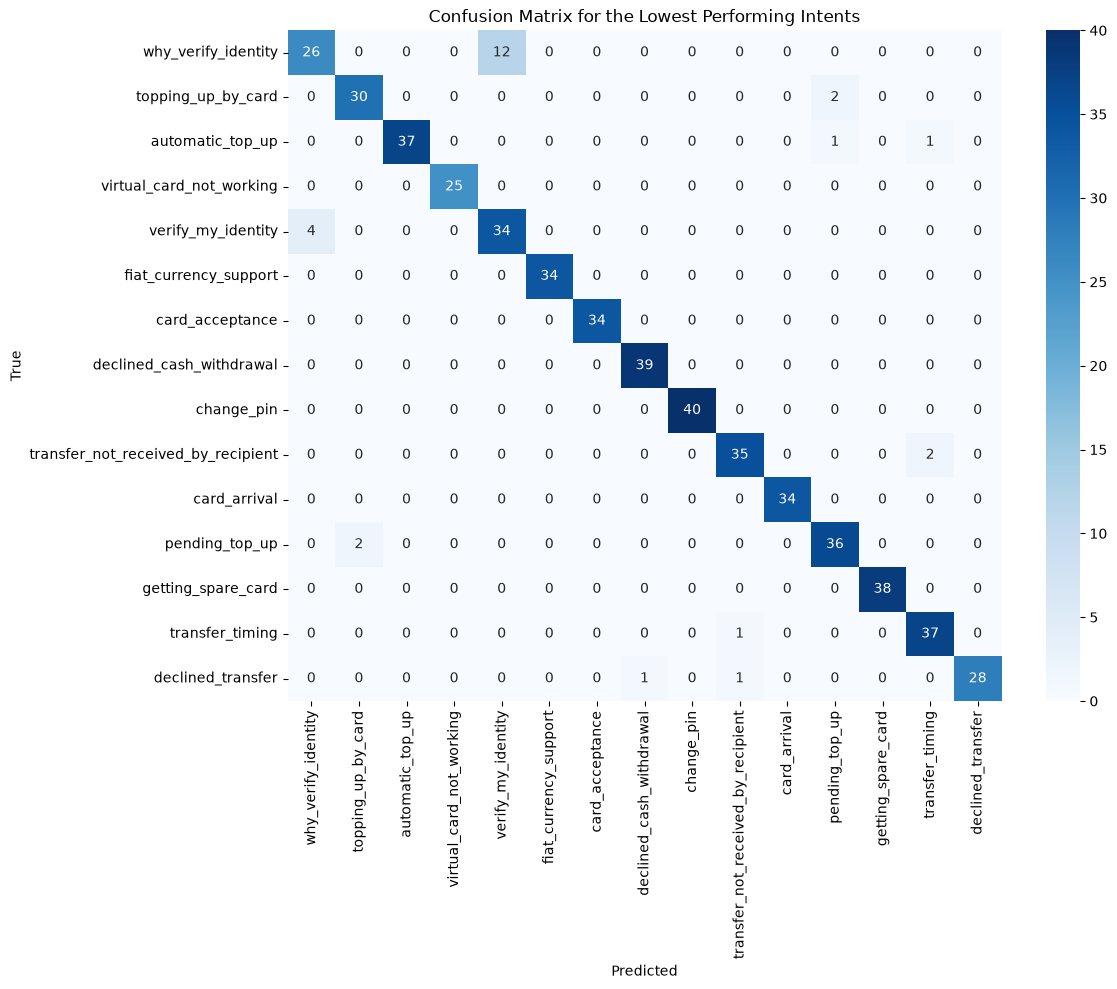

In [12]:
worst_intents = intent_report.head(15).index.tolist()

mask = (
    test_df["label_text"].isin(worst_intents)
)

subset = test_df.loc[mask]

cm = confusion_matrix(
    subset["label_text"],
    subset["prediction"].map(model.config.id2label),
    labels=worst_intents,
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    xticklabels=worst_intents,
    yticklabels=worst_intents,
    cmap="Blues",
    annot=True,
    fmt="d",
)

plt.title("Confusion Matrix for the Lowest Performing Intents")

plt.xlabel("Predicted")

plt.ylabel("True")

plt.tight_layout()

plt.show()

7. ТОП-20 найчастіших помилок

In [14]:
id2label = model.config.id2label

test_df["prediction_label"] = (
    test_df["prediction"]
    .map(id2label)
)

In [15]:
errors = test_df[
    test_df["correct"] == False
]

top_errors = (
    errors
    .groupby(
        [
            "label_text",
            "prediction_label",
        ]
    )
    .size()
    .reset_index(name="count")
    .sort_values(
        "count",
        ascending=False,
    )
)

top_errors.head(20)

,label_text,prediction_label,count
169,why_verify_identity,verify_my_identity,12
163,virtual_card_not_working,get_disposable_virtual_card,6
164,virtual_card_not_working,getting_virtual_card,6
85,get_disposable_virtual_card,getting_virtual_card,5
28,card_delivery_estimate,card_arrival,5
26,card_arrival,card_delivery_estimate,5
9,balance_not_updated_after_bank_transfer,transfer_timing,4
51,compromised_card,terminate_account,4
70,disposable_card_limits,get_disposable_virtual_card,4
7,balance_not_updated_after_bank_transfer,pending_transfer,4


8. Порівняння confidence для правильних і помилкових прогнозів

In [18]:
confidence_summary = (
    test_df
    .groupby("correct")["confidence"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max",
    )
)

confidence_summary.index = confidence_summary.index.map({
    True: "Correct",
    False: "Incorrect",
})

confidence_summary

,count,mean,median,std,min,max
correct,,,,,,
Incorrect,279,0.550648,0.549102,0.212691,0.095988,0.960096
Correct,2801,0.870682,0.924623,0.139965,0.179106,0.986700


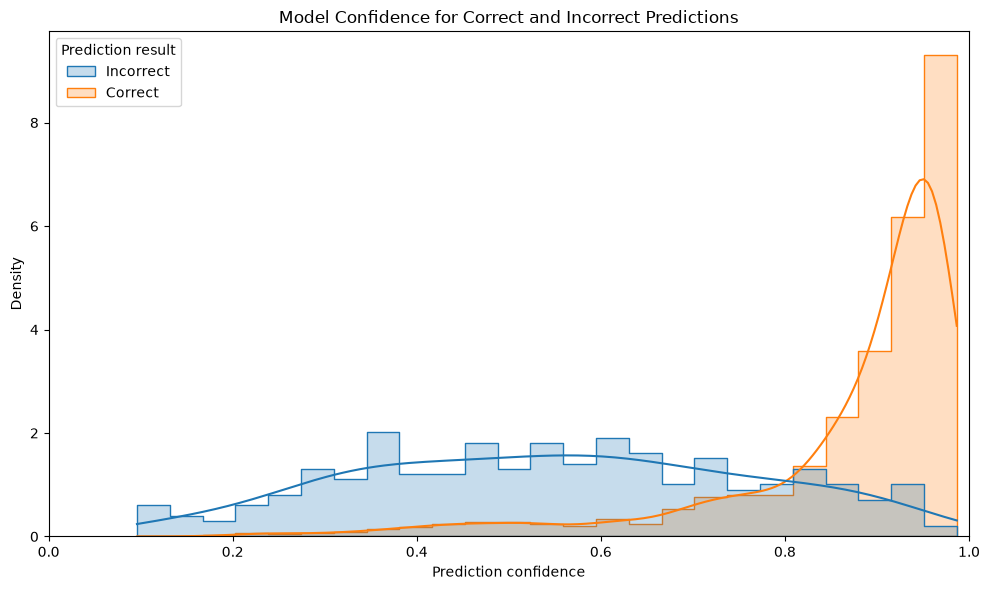

In [19]:
plot_df = test_df.copy()

plot_df["Prediction result"] = plot_df["correct"].map({
    True: "Correct",
    False: "Incorrect",
})

plt.figure(figsize=(10, 6))

sns.histplot(
    data=plot_df,
    x="confidence",
    hue="Prediction result",
    bins=25,
    kde=True,
    stat="density",
    common_norm=False,
    element="step",
)

plt.title("Model Confidence for Correct and Incorrect Predictions")
plt.xlabel("Prediction confidence")
plt.ylabel("Density")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

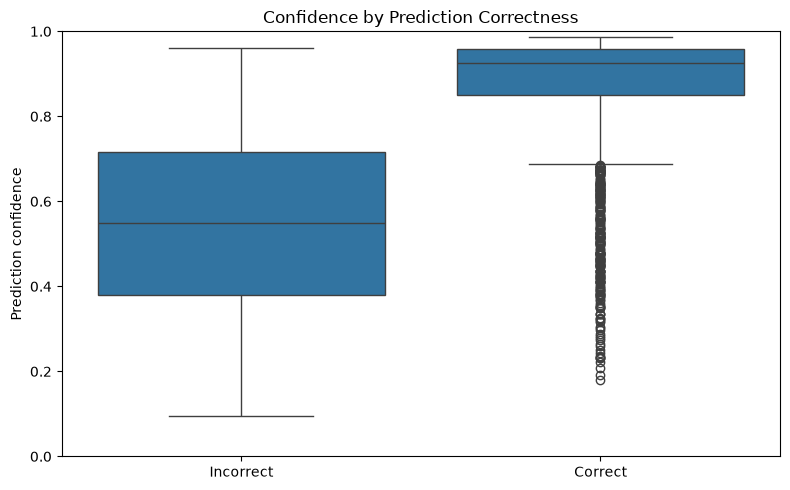

In [20]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=plot_df,
    x="Prediction result",
    y="confidence",
)

plt.title("Confidence by Prediction Correctness")
plt.xlabel("")
plt.ylabel("Prediction confidence")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

9. Частка помилок із високою впевненістю

In [21]:
incorrect_predictions = test_df[
    ~test_df["correct"]
].copy()

high_confidence_errors = incorrect_predictions[
    incorrect_predictions["confidence"] >= 0.90
]

print("Total errors:", len(incorrect_predictions))
print(
    "High-confidence errors:",
    len(high_confidence_errors),
)
print(
    "Share of high-confidence errors:",
    len(high_confidence_errors)
    / len(incorrect_predictions)
)

Total errors: 279
High-confidence errors: 13
Share of high-confidence errors: 0.04659498207885305


In [22]:
high_confidence_errors[
    [
        "text",
        "label_text",
        "prediction_label",
        "confidence",
    ]
].sort_values(
    "confidence",
    ascending=False,
).head(15)

,text,label_text,prediction_label,confidence
1866,I would like to know why my payment is still p...,pending_transfer,pending_card_payment,0.960096
2763,Where do I find the exchange rate?,exchange_charge,exchange_rate,0.953637
775,My cash withdrawal was partly declined,wrong_amount_of_cash_received,declined_cash_withdrawal,0.947620
2711,My transfer is pending.,balance_not_updated_after_bank_transfer,pending_transfer,0.946752
2761,whats your exchange rate,exchange_charge,exchange_rate,0.945311
1626,"I was double charged, and the second charge is...",pending_card_payment,transaction_charged_twice,0.939926
368,How do I unblock my card using the app?,card_not_working,pin_blocked,0.934140
521,Where can I view my PIN?,pin_blocked,get_physical_card,0.932778
264,Am I able to exchange currencies?,fiat_currency_support,exchange_via_app,0.924472
2544,My card is just not working at this time.,virtual_card_not_working,card_not_working,0.923864


Висновок

Проведений аналіз помилок показав, що fine-tuned DistilBERT демонструє високу та відносно рівномірну якість класифікації для більшості з наведених у датасеті банківських категорій. Навіть найскладніші категорії зберігають прийнятний рівень F1-score, а основні помилки виникають не між випадковими класами, а між семантично близькими запитами клієнтів. Інші помилки також переважно спостерігаються всередині тематично споріднених груп: операцій поповнення рахунку, карткових операцій і банківських переказів. Це свідчить про те, що модель добре розрізняє загальні банківські теми, але іноді має складнощі з більш тонкими відмінностями між подібними підтипами звернень. Загалом модель показала хорошу узагальнюючу здатність і для використання даної моделі у продуктиві, варто було б натренувати модель на більшій кількості запитів у семантично близьких класах.